# 02 - Reproducible Prediction Demo
## Digital Banking Customer Churn Prediction

This notebook is independent of the training notebook/scripts: it only loads the saved pipeline
artifact (`artifacts/churn_pipeline.joblib`) and calls `predict_churn_risk()`. Restarting the kernel
and running top-to-bottom does not depend on any earlier training state.

It has two parts:
1. **How it works, step by step** — walking through what happens inside `predict_churn_risk()` for one customer
2. **Risk scoring in action** — running the full function on several example customers, plus a visual gauge

**Reminder:** this model is a decision-support signal for a retention team, not an automatic decision.
Every high-risk flag should go through human review before any action is taken with a customer.


In [1]:
# Add the src/ folder to the path so we can import our own churn_predictor package
import sys
sys.path.insert(0, "../src")

from churn_predictor.predict import predict_churn_risk, validate_customer_data, InvalidCustomerData
from churn_predictor.preprocessing import FEATURE_COLUMNS
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load the same saved pipeline that predict_churn_risk() uses internally,
# so we can peek inside each step instead of only seeing the final answer
pipeline = joblib.load("../artifacts/churn_pipeline.joblib")

## Part 1 - How It Works, Step by Step
One customer record, walked through every stage of the pipeline.

In [2]:
# Step 1: start with a raw customer record - exactly what a retention-team tool would send in
sample_customer = {
    "CreditScore": 580, "Geography": "Germany", "Gender": "Female", "Age": 58,
    "Tenure": 1, "Balance": 130000.0, "NumOfProducts": 1, "HasCrCard": 0,
    "IsActiveMember": 0, "EstimatedSalary": 40000.0,
}
sample_customer

{'CreditScore': 580,
 'Geography': 'Germany',
 'Gender': 'Female',
 'Age': 58,
 'Tenure': 1,
 'Balance': 130000.0,
 'NumOfProducts': 1,
 'HasCrCard': 0,
 'IsActiveMember': 0,
 'EstimatedSalary': 40000.0}

In [3]:
# Step 2: validate - this is the same check predict_churn_risk() runs internally.
# It raises InvalidCustomerData if a field is missing, unexpected, or out of a realistic range.
validate_customer_data(sample_customer)
print("Input passed validation.")

Input passed validation.


In [4]:
# Step 3: preprocess - turn the raw dict into the exact scaled/encoded row the model was trained on.
# This uses the SAME fitted transformer from training, loaded from the saved pipeline.
row = pd.DataFrame([{col: sample_customer[col] for col in FEATURE_COLUMNS}])
transformed = pipeline.named_steps["preprocess"].transform(row)

print("Raw input columns: ", list(row.columns))
print("Transformed shape:  ", transformed.shape, "(scaled numbers + one-hot encoded categories)")

Raw input columns:  ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'HasCrCard', 'IsActiveMember', 'Geography', 'Gender']
Transformed shape:   (1, 12) (scaled numbers + one-hot encoded categories)


In [5]:
# Step 4: predict - the trained Random Forest turns the transformed row into a churn probability
raw_probability = pipeline.named_steps["model"].predict_proba(transformed)[0, 1]
print(f"Raw model output (probability customer churns): {raw_probability:.4f}")

Raw model output (probability customer churns): 0.9294


In [6]:
# Step 5: explain - wrap the raw number into something a retention team can actually act on
result = predict_churn_risk(sample_customer)
result

{'churn_probability': 0.9294,
 'risk_label': 'high_risk',
 'message': 'High churn risk. Recommend proactive retention outreach.'}

Notice the probability in `result` matches the raw model output from Step 4 — `predict_churn_risk()` doesn't change the number, it just adds validation and a plain-language label around it.

## Part 2 - Risk Scoring in Action
Three example customers, run through the same function.

In [7]:
# A low-risk profile: long tenure, multiple products, still active
low_risk_customer = {
    "CreditScore": 720, "Geography": "France", "Gender": "Male", "Age": 33,
    "Tenure": 8, "Balance": 45000.0, "NumOfProducts": 2, "HasCrCard": 1,
    "IsActiveMember": 1, "EstimatedSalary": 85000.0,
}
predict_churn_risk(low_risk_customer)

{'churn_probability': 0.106,
 'risk_label': 'low_risk',
 'message': 'Low churn risk. No action needed.'}

In [8]:
# A moderate-risk profile: short tenure, single product, but still active
moderate_risk_customer = {
    "CreditScore": 619, "Geography": "France", "Gender": "Female", "Age": 42,
    "Tenure": 2, "Balance": 0.0, "NumOfProducts": 1, "HasCrCard": 1,
    "IsActiveMember": 1, "EstimatedSalary": 101348.88,
}
predict_churn_risk(moderate_risk_customer)

{'churn_probability': 0.6223,
 'risk_label': 'high_risk',
 'message': 'High churn risk. Recommend proactive retention outreach.'}

In [9]:
# The high-risk profile from Part 1, for side-by-side comparison
predict_churn_risk(sample_customer)

{'churn_probability': 0.9294,
 'risk_label': 'high_risk',
 'message': 'High churn risk. Recommend proactive retention outreach.'}

### Invalid input is rejected, not silently guessed at

In [10]:
# Remove a required field and confirm the function refuses to guess a default
bad_customer = sample_customer.copy()
del bad_customer["Balance"]

try:
    predict_churn_risk(bad_customer)
except InvalidCustomerData as e:
    print(f"Rejected as expected: {e}")

Rejected as expected: Missing required field(s): ['Balance']


### Visual risk gauge
The same three probabilities as a gauge, so a non-technical reviewer can read the result at a glance.

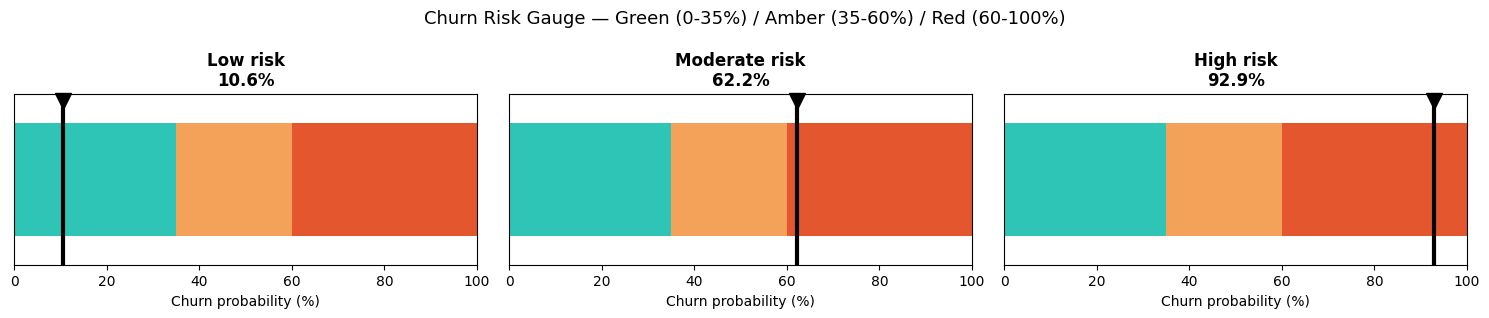

In [11]:
def plot_risk_gauge(ax, probability, label):
    """Draw a single 0-100% gauge with three colored risk zones and a marker
    at the customer's actual predicted probability."""
    # Draw the three risk zones as stacked horizontal bar segments
    ax.barh(0, 35, color="#2EC4B6", left=0)     # low risk: 0-35%
    ax.barh(0, 25, color="#F4A259", left=35)    # moderate risk: 35-60%
    ax.barh(0, 40, color="#E4572E", left=60)    # high risk: 60-100%

    # Mark this customer's probability with a black vertical line + triangle
    pct = probability * 100
    ax.axvline(pct, color="black", linewidth=3)
    ax.plot(pct, 0.55, marker="v", color="black", markersize=12, clip_on=False)

    ax.set_xlim(0, 100)
    ax.set_ylim(-0.6, 0.6)
    ax.set_yticks([])
    ax.set_xlabel("Churn probability (%)")
    ax.set_title(f"{label}\n{pct:.1f}%", fontsize=12, fontweight="bold")


# Run all three examples through the model and plot them side by side
examples = [
    ("Low risk", low_risk_customer),
    ("Moderate risk", moderate_risk_customer),
    ("High risk", sample_customer),
]

fig, axs = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, (label, customer) in zip(axs, examples):
    prob = predict_churn_risk(customer)["churn_probability"]
    plot_risk_gauge(ax, prob, label)

fig.suptitle("Churn Risk Gauge — Green (0-35%) / Amber (35-60%) / Red (60-100%)", fontsize=13)
plt.tight_layout()
plt.show()

## Human-review reminder

`predict_churn_risk()` returns a probability and a plain-language message, never a final action. High-risk flags
should route to a retention team for review, not to an automated account action — see `docs/RESPONSIBLE_AI.md`.
